In [ ]:
import os
import zipfile
import librosa
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. SETUP PATHS ---
zip_path = r'C:\Users\prash\OneDrive\Desktop\Language Classifier\archive (6).zip'
extract_to = r'C:\Users\prash\OneDrive\Desktop\Language Classifier\extracted_data'

# Unzip the dataset
if not os.path.exists(extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# --- 2. PREPROCESSING & FEATURE EXTRACTION ---
def extract_features(file_path):
    try:
        # Load MP3 (Properly resampled to 16kHz)
        y, sr = librosa.load(file_path, sr=16000)
        y, _ = librosa.effects.trim(y) # Remove silence
        
        # Extract Feature Stack for Descent Accuracy
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
        
        return np.hstack([mfcc, chroma, contrast])
    except Exception as e:
        return None

# Loop through folders and extract
X, y_labels = [], []
for root, dirs, files in os.walk(extract_to):
    for file in files:
        if file.endswith('.mp3'):
            lang_label = os.path.basename(root)
            feat = extract_features(os.path.join(root, file))
            if feat is not None:
                X.append(feat)
                y_labels.append(lang_label)

# Encode labels and scale features
le = LabelEncoder()
y = le.fit_transform(y_labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(np.array(X))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- 3. TRAIN & SAVE 3 MODELS ---
models = {
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='rbf', probability=True)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    # Save the small trained models (~20KB - 80KB)
    joblib.dump(model, f"{name}_language_model.pkl")
    print(f"Saved {name}_language_model.pkl")

# Save the label encoder and scaler for later use
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')


In [1]:
pip install librosa numpy soundfile joblib scikit-learn xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 11.2 MB/s eta 0:00:10
    --------------------------------------- 1.3/101.7 MB 3.7 MB/s eta 0:00:27
    --------------------------------------- 2.1/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.1/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.1/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.1/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 2.1/101.7 MB 4.5 MB/s eta 0:00:23
   - -------------------------------------- 3.1/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 4.2/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 5.0/101.7 MB 2.4 MB/s eta 0:00:41
   -- ------------------------------------- 5.8/101.7 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 6.3/101.7 MB 2.6 MB/s eta 

In [2]:
pip install audioread


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import zipfile
import librosa
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. SETUP PATHS ---
zip_path = r'C:\Users\prash\OneDrive\Desktop\Language Classifier\archive (6).zip'
extract_to = r'C:\Users\prash\OneDrive\Desktop\Language Classifier\extracted_data'

# Unzip the dataset
if not os.path.exists(extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# --- 2. PREPROCESSING & FEATURE EXTRACTION ---
def extract_features(file_path):
    try:
        # Load MP3 (Properly resampled to 16kHz)
        y, sr = librosa.load(file_path, sr=16000)
        y, _ = librosa.effects.trim(y) # Remove silence
        
        # Extract Feature Stack for Descent Accuracy
        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
        
        return np.hstack([mfcc, chroma, contrast])
    except Exception as e:
        return None

# Loop through folders and extract
X, y_labels = [], []
for root, dirs, files in os.walk(extract_to):
    for file in files:
        if file.endswith('.mp3'):
            lang_label = os.path.basename(root)
            feat = extract_features(os.path.join(root, file))
            if feat is not None:
                X.append(feat)
                y_labels.append(lang_label)

# Encode labels and scale features
le = LabelEncoder()
y = le.fit_transform(y_labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(np.array(X))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- 3. TRAIN & SAVE 3 MODELS ---
models = {
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='rbf', probability=True)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    # Save the small trained models (~20KB - 80KB)
    joblib.dump(model, f"{name}_language_model.pkl")
    print(f"Saved {name}_language_model.pkl")

# Save the label encoder and scaler for later use
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')


c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Training XGBoost...
Saved XGBoost_language_model.pkl
Training RandomForest...
Saved RandomForest_language_model.pkl
Training SVM...
Saved SVM_language_model.pkl


['feature_scaler.pkl']

In [4]:
import librosa
import numpy as np
import joblib
import os

# --- 1. CONFIGURATION ---
base_path = r'C:\Users\prash\OneDrive\Desktop\Language Classifier'
test_audio = os.path.join(base_path, r'extracted_data\Indian_Languages_Audio_Dataset\Hindi\36.mp3')

# Resource paths
scaler_path = os.path.join(base_path, 'feature_scaler.pkl')
encoder_path = os.path.join(base_path, 'label_encoder.pkl')

# Model filenames
model_files = {
    "XGBoost": "XGBoost_language_model.pkl",
    "RandomForest": "RandomForest_language_model.pkl",
    "SVM": "SVM_language_model.pkl"
}

def extract_features(file_path):
    """Must match training preprocessing exactly."""
    y, sr = librosa.load(file_path, sr=16000)
    y, _ = librosa.effects.trim(y)
    
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
    
    return np.hstack([mfcc, chroma, contrast]).reshape(1, -1)

def run_all_predictions():
    # Load Preprocessing Tools
    scaler = joblib.load(scaler_path)
    le = joblib.load(encoder_path)

    # Preprocess Audio
    print(f"Processing: {os.path.basename(test_audio)}...")
    features = extract_features(test_audio)
    features_scaled = scaler.transform(features)

    print("\n" + "="*40)
    print(f"{'ALGORITHM':<15} | {'PREDICTION':<12} | {'CONFIDENCE'}")
    print("-" * 40)

    for name, filename in model_files.items():
        model_path = os.path.join(base_path, filename)
        
        if os.path.exists(model_path):
            model = joblib.load(model_path)
            
            # Predict
            pred_idx = model.predict(features_scaled)
            language = le.inverse_transform(pred_idx)[0]
            
            # Confidence (Probability)
            probs = model.predict_proba(features_scaled)
            confidence = np.max(probs) * 100
            
            print(f"{name:<15} | {language:<12} | {confidence:>8.2f}%")
        else:
            print(f"{name:<15} | File not found.")

    print("="*40)

if __name__ == "__main__":
    run_all_predictions()


Processing: 36.mp3...

ALGORITHM       | PREDICTION   | CONFIDENCE
----------------------------------------
XGBoost         | Hindi        |    96.00%
RandomForest    | Hindi        |    60.00%
SVM             | Hindi        |    82.79%


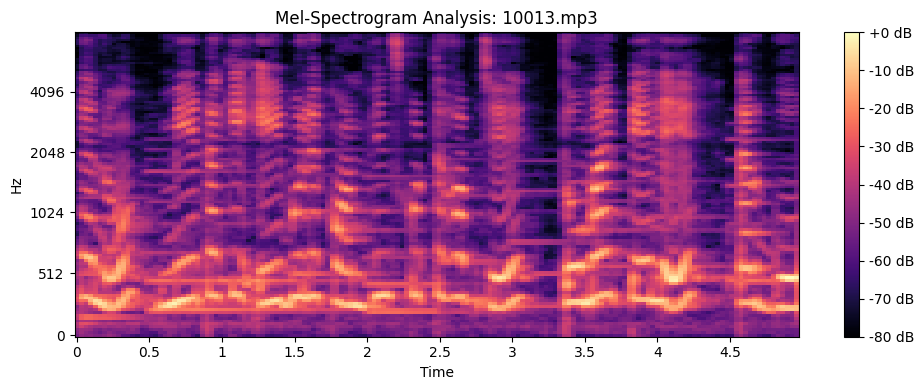

c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


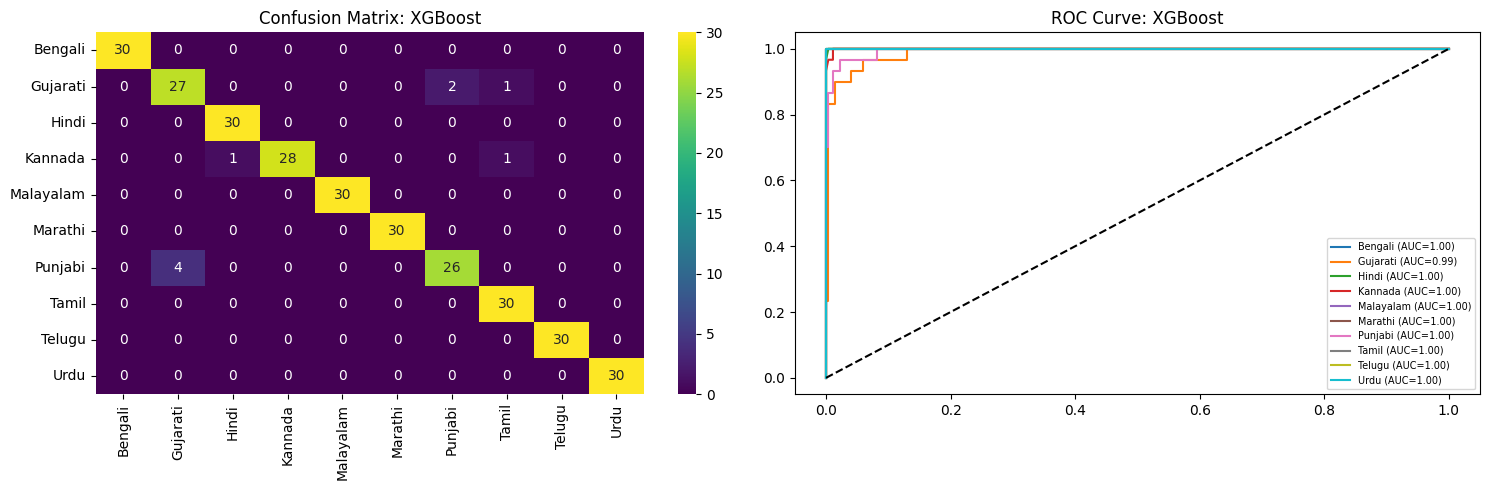

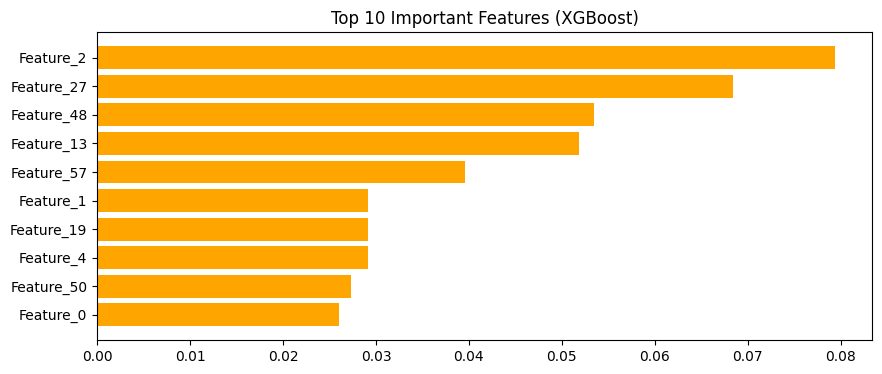

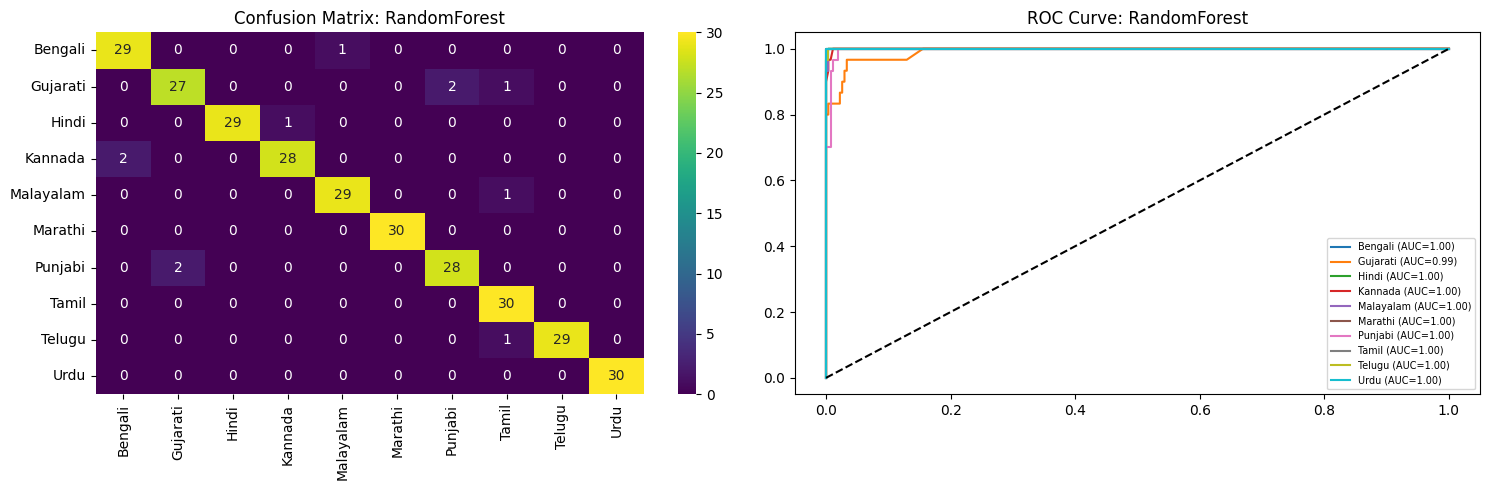

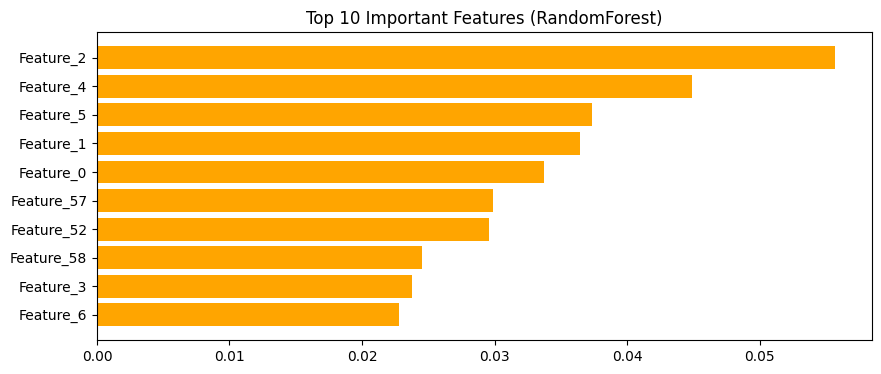

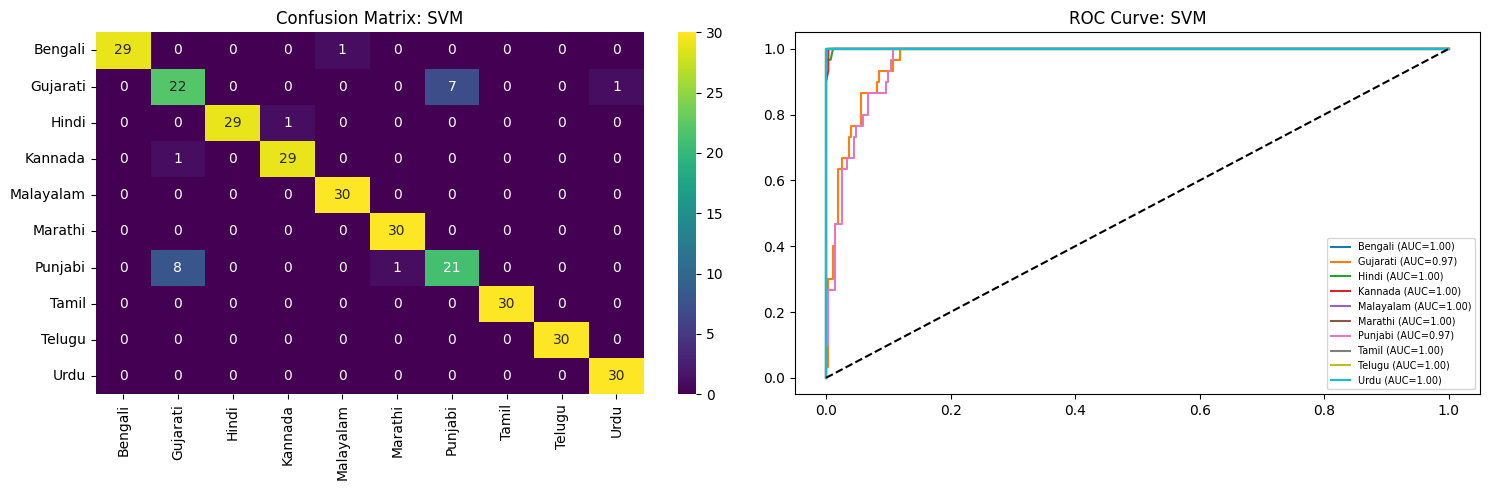

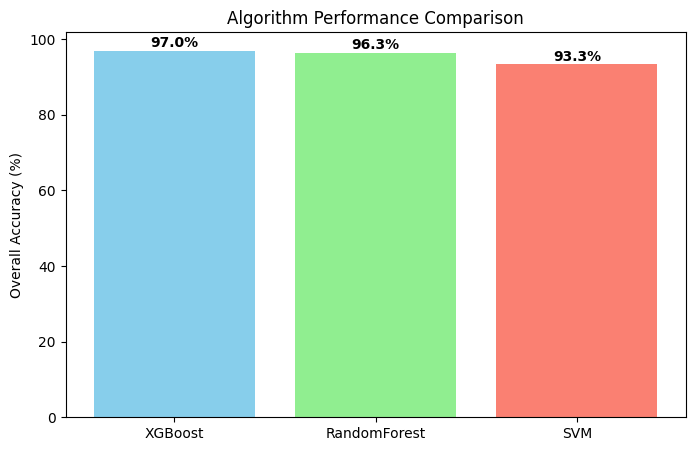

In [1]:
import librosa
import librosa.display
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- 1. CONFIGURATION ---
base_path = r'C:\Users\prash\OneDrive\Desktop\Language Classifier'
# Point this to your TEST folder (should contain subfolders like 'Hindi', 'Tamil', etc.)
test_data_path = os.path.join(base_path, r'extracted_data\Indian_Languages_Audio_Dataset')

scaler_path = os.path.join(base_path, 'feature_scaler.pkl')
encoder_path = os.path.join(base_path, 'label_encoder.pkl')

model_files = {
    "XGBoost": "XGBoost_language_model.pkl",
    "RandomForest": "RandomForest_language_model.pkl",
    "SVM": "SVM_language_model.pkl"
}

# --- 2. AUDIO VISUALIZATION (DATA PROCESSING SECTION) ---
def plot_sample_spectrogram(file_path):
    """Generates a Mel-Spectrogram to show how the model 'sees' the audio."""
    if not os.path.exists(file_path):
        return
    
    y, sr = librosa.load(file_path, sr=16000)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel-Spectrogram Analysis: {os.path.basename(file_path)}")
    plt.tight_layout()
    plt.show()

# --- 3. FEATURE EXTRACTION & DATA LOADING ---
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    y, _ = librosa.effects.trim(y)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
    return np.hstack([mfcc, chroma, contrast])

def load_test_dataset(test_dir, le):
    features_list, labels_list = [], []
    for lang in le.classes_:
        lang_folder = os.path.join(test_dir, lang)
        if not os.path.exists(lang_folder): continue
        
        # Take 20-30 samples per language for evaluation
        files = [f for f in os.listdir(lang_folder) if f.endswith('.mp3')][:30]
        for f in files:
            try:
                feat = extract_features(os.path.join(lang_folder, f))
                features_list.append(feat)
                labels_list.append(lang)
            except: continue
    return np.array(features_list), le.transform(labels_list)

# --- 4. MAIN EVALUATION LOOP ---
def run_full_results_dashboard():
    # Load Preprocessing Tools
    scaler = joblib.load(scaler_path)
    le = joblib.load(encoder_path)
    class_names = le.classes_
    
    # 1. Show a Sample Spectrogram first
    sample_lang_dir = os.path.join(test_data_path, class_names[0])
    if os.path.exists(sample_lang_dir):
        sample_file = os.path.join(sample_lang_dir, os.listdir(sample_lang_dir)[0])
        plot_sample_spectrogram(sample_file)

    # 2. Load and Scale Test Data
    X_raw, y_test = load_test_dataset(test_data_path, le)
    X_test = scaler.transform(X_raw)
    
    model_accuracies = {}

    for name, filename in model_files.items():
        model_path = os.path.join(base_path, filename)
        if not os.path.exists(model_path): continue
        
        model = joblib.load(model_path)
        y_pred = model.predict(X_test)
        y_probs = model.predict_proba(X_test)
        
        # Store accuracy for final comparison
        acc = np.sum(y_pred == y_test) / len(y_test) * 100
        model_accuracies[name] = acc

        # --- Dashboard per Model ---
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # A. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
                    xticklabels=class_names, yticklabels=class_names, ax=axes[0])
        axes[0].set_title(f'Confusion Matrix: {name}')

        # B. ROC Curve
        y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
            axes[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC={auc(fpr, tpr):.2f})')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title(f'ROC Curve: {name}')
        axes[1].legend(loc='lower right', fontsize='x-small')
        
        plt.tight_layout()
        plt.show()

        # C. Feature Importance (XGB/RF only)
        if hasattr(model, 'feature_importances_'):
            plt.figure(figsize=(10, 4))
            importances = model.feature_importances_
            indices = np.argsort(importances)[-10:] # Top 10 features
            plt.barh(range(10), importances[indices], color='orange')
            plt.yticks(range(10), [f"Feature_{i}" for i in indices])
            plt.title(f"Top 10 Important Features ({name})")
            plt.show()

    # --- 5. FINAL COMPARISON BAR CHART ---
    plt.figure(figsize=(8, 5))
    plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['skyblue', 'lightgreen', 'salmon'])
    plt.ylabel('Overall Accuracy (%)')
    plt.title('Algorithm Performance Comparison')
    for i, v in enumerate(model_accuracies.values()):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
    plt.show()

if __name__ == "__main__":
    run_full_results_dashboard()